# Polities — how individuals are assigned to Cliopatria polities, and their activity per polity and century

In [1]:
import json
import random
import tempfile

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib import patheffects
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch, Polygon
from shapely.geometry import box, shape

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
BASEMAP_PATH = '../data/legacy/ne_110m_admin_0_countries.geojson'

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

COLORS = {
    'navy':       '#1f3a5f',
    'teal':       '#0f766e',
    'orange':     '#d97706',
    'grey':       '#6b7280',
    'light_grey': '#f3f4f6',
    'light_blue': '#dbe4ee',
    'light_teal': '#cce7e2',
    'basemap':    '#9a9a9a',
}
MAP_COLORMAP = 'YlGnBu'

CENTURY_SNAPSHOTS = [-400, 500, 1400, 1900]
MIDDLE_EAST_CENTURIES = [-400, 700, 1200, 1600]
MIDDLE_EAST_BOUNDS = (30.0, 12.0, 65.0, 43.0)
MIDDLE_EAST_LABELS = 6
LABEL_MIN_GAP = (7.0, 3.0)

plt.rcParams.update({
    'figure.dpi':        120,
    'figure.figsize':    (13, 7.5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.labelsize':    16,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'legend.fontsize':   14,
})

## External data

- `../data/legacy/ne_110m_admin_0_countries.geojson` — Natural Earth 1:110m country borders, used only as a grey basemap under the polity maps.

In [2]:
basemap = gpd.read_file(BASEMAP_PATH)
print('basemap countries:', len(basemap))

basemap countries: 177


## Load data

### Polity matches — one row per (individual, polity), with the assignation method

`individual_enriched.polity[].assignation_method` replaces the old `individuals_cliopatria.method/origin`.
Only the polity id and name are unnested (the geometries stay in `polity.territories`).

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='3GB'; SET threads=4; SET temp_directory='{tempfile.mkdtemp()}';")

MATCHES_SQL = """
    SELECT entity.qid                    AS qid,
           p.polity.cliopatria_id        AS polity_id,
           p.polity.name                 AS polity_name,
           p.years_spent_in_polity       AS years_spent_in_polity,
           p.assignation_method          AS assignation_method,
           peak_productivity.start_year  AS peak_start,
           peak_productivity.end_year    AS peak_end
    FROM   (SELECT entity, peak_productivity, unnest(polity) AS p FROM individual_enriched)
"""

method_counts = con.sql(f"""
    SELECT assignation_method, COUNT(*) AS n_matches, COUNT(DISTINCT qid) AS n_individuals
    FROM   ({MATCHES_SQL})
    GROUP  BY assignation_method
""").pl()

methods_per_individual = con.sql("""
    SELECT MAX(len(list_distinct(list_transform(polity, x -> x.assignation_method)))) AS max_methods
    FROM   individual_enriched
""").fetchone()[0]
assert methods_per_individual == 1, 'each individual is matched by a single method'
print('methods per individual (max):', methods_per_individual)
method_counts

methods per individual (max): 1


assignation_method,n_matches,n_individuals
str,i64,i64
"""polygon_of_deathplace""",2595716,1465375
"""polygon_of_birthplace""",2815866,2034937
"""url_of_country_of_citizenship""",68681,68298
"""url_of_birthplace""",331,330
"""polygon_of_country_of_citizenship""",2099097,1589979
"""url_of_deathplace""",56,53


### Denominators — total, with a peak-productivity window, with a window AND a location

In [4]:
denominators = con.sql("""
    SELECT COUNT(*)                                                  AS n_individuals,
           COUNT(e.peak_productivity.start_year)                     AS n_dated,
           COUNT(*) FILTER (WHERE e.peak_productivity.start_year IS NOT NULL
                              AND (i.place_of_birth IS NOT NULL OR i.place_of_death IS NOT NULL
                                   OR len(i.country_of_citizenship) > 0)) AS n_dated_and_located,
           COUNT(*) FILTER (WHERE len(e.polity) > 0)                 AS n_matched
    FROM   individual_enriched AS e
    JOIN   individual AS i ON i.entity.qid = e.entity.qid
""").pl().row(0, named=True)

n_individuals, n_dated = denominators['n_individuals'], denominators['n_dated']
assert denominators['n_matched'] == method_counts['n_individuals'].sum()
for key, value in denominators.items():
    print(f'{key:22s}: {value:,}')

n_individuals         : 13,002,897
n_dated               : 9,709,528
n_dated_and_located   : 5,258,306
n_matched             : 5,158,972


### Active individuals per polity and century (all, scientists)

For each century `[c, c+99]`, count individuals whose peak-productivity window overlaps the century, per polity.
Scientists = `individual.is_scientist` (replaces the old `occupations.meta_occupation = 'scientist'`).

In [5]:
ALL_CENTURIES = sorted(set(CENTURY_SNAPSHOTS + MIDDLE_EAST_CENTURIES))

century_counts = con.sql(f"""
    WITH matches AS ({MATCHES_SQL}),
    centuries AS (SELECT unnest($centuries) AS century)
    SELECT c.century, m.polity_id, m.polity_name,
           COUNT(*)                                  AS n_all,
           COUNT(*) FILTER (WHERE i.is_scientist)    AS n_scientists
    FROM   matches AS m
    JOIN   centuries AS c ON m.peak_start <= c.century + 99 AND m.peak_end >= c.century
    JOIN   individual AS i ON i.entity.qid = m.qid
    GROUP  BY ALL
""", params={'centuries': ALL_CENTURIES}).pl()

assert century_counts.select('century', 'polity_id').is_duplicated().sum() == 0
print('shape:', century_counts.shape)
century_counts.sort('n_all', descending=True).head()

shape: (4359, 5)


century,polity_id,polity_name,n_all,n_scientists
i32,i64,str,i64,i64
1900,1148,"""United States of America""",509546,94630
1900,1389,"""Union of Soviet Socialist Republics""",395706,95273
1900,1412,"""Nazi Germany""",289259,49731
1900,1097,"""British Empire""",248786,37371
1900,1102,"""Kingdom of Great Britain""",198793,30640


### Representative polygon per (polity, century)

From `polity.territories`: among the territory periods overlapping the century, the one whose midpoint is
closest to `c + 50`. Only the selected geometries are pulled.

In [6]:
polygons = con.sql("""
    WITH territories AS (
        SELECT cliopatria_id AS polity_id, name AS polity_name, t.start_year, t.end_year, t.geometry
        FROM   (SELECT cliopatria_id, name, unnest(territories) AS t FROM polity)
    ),
    candidates AS (
        SELECT c.century, territories.*,
               row_number() OVER (PARTITION BY c.century, polity_id
                                  ORDER BY abs((start_year + end_year) / 2.0 - (c.century + 50)), start_year) AS rk
        FROM   territories
        JOIN   (SELECT unnest($centuries) AS century) AS c
          ON   start_year <= c.century + 99 AND end_year >= c.century
    )
    SELECT century, polity_id, polity_name, start_year, end_year, geometry
    FROM   candidates
    WHERE  rk = 1
""", params={'centuries': ALL_CENTURIES}).pl()

con.close()

assert polygons.select('century', 'polity_id').is_duplicated().sum() == 0
print('shape:', polygons.shape)
print(polygons.group_by('century').len().sort('century'))
polygons.drop('geometry').head()

shape: (1276, 6)
shape: (7, 2)
┌─────────┬─────┐
│ century ┆ len │
│ ---     ┆ --- │
│ i32     ┆ u32 │
╞═════════╪═════╡
│ -400    ┆ 57  │
│ 500     ┆ 109 │
│ 700     ┆ 116 │
│ 1200    ┆ 265 │
│ 1400    ┆ 233 │
│ 1600    ┆ 151 │
│ 1900    ┆ 345 │
└─────────┴─────┘


century,polity_id,polity_name,start_year,end_year
i32,i64,str,i64,i64
-400,44,"""Qin""",-350,-338
-400,65,"""Macedonian Empire""",-350,-338
-400,104,"""Thirtieth Dynasty of Egypt""",-350,-338
-400,114,"""Ptolemaic Kingdom""",-331,-327
-400,115,"""Cyrenaica""",-331,-292


## Preprocessing

### Linkage breakdown — cascade order

The cascade tries, per individual, polygon of deathplace → birthplace → country of citizenship, then URL
matching on citizenship → deathplace → birthplace; the first step that yields a match is kept for all that
individual's polities. `n_matches` counts (individual, polity) pairs, `n_individuals` distinct individuals.

In [7]:
CASCADE_ORDER = [
    ('polygon_of_deathplace',             'Polygon merging', 'Place of death'),
    ('polygon_of_birthplace',             'Polygon merging', 'Place of birth'),
    ('polygon_of_country_of_citizenship', 'Polygon merging', 'Country of citizenship'),
    ('url_of_country_of_citizenship',     'URL matching',    'Country of citizenship'),
    ('url_of_deathplace',                 'URL matching',    'Place of death'),
    ('url_of_birthplace',                 'URL matching',    'Place of birth'),
]

cascade = (
    pl.DataFrame(CASCADE_ORDER, schema=['assignation_method', 'method', 'origin'], orient='row')
    .with_row_index('step', offset=1)
    .join(method_counts, on='assignation_method', how='left')
    .with_columns(pl.col('n_matches', 'n_individuals').fill_null(0))
    .with_columns((pl.col('n_matches') / pl.col('n_matches').sum() * 100).round(1).alias('pct_of_matches'))
)

assert cascade['n_individuals'].sum() == denominators['n_matched']
print(f'{cascade["n_matches"].sum():,} (individual, polity) matches for {denominators["n_matched"]:,} individuals')
cascade.select('step', 'method', 'origin', 'n_matches', 'pct_of_matches', 'n_individuals')

7,579,747 (individual, polity) matches for 5,158,972 individuals


step,method,origin,n_matches,pct_of_matches,n_individuals
u32,str,str,i64,f64,i64
1,"""Polygon merging""","""Place of death""",2595716,34.2,1465375
2,"""Polygon merging""","""Place of birth""",2815866,37.1,2034937
3,"""Polygon merging""","""Country of citizenship""",2099097,27.7,1589979
4,"""URL matching""","""Country of citizenship""",68681,0.9,68298
5,"""URL matching""","""Place of death""",56,0.0,53
6,"""URL matching""","""Place of birth""",331,0.0,330


### Recursive coverage — share of individuals added per cascade step, and cumulative

In [8]:
coverage = (
    cascade
    .with_columns(
        (pl.col('n_individuals') / n_dated * 100).alias('share_of_dated_pct'),
        (pl.col('n_individuals') / n_individuals * 100).alias('share_of_total_pct'),
    )
    .with_columns(
        pl.col('share_of_dated_pct').cum_sum().alias('cumulative_dated_pct'),
        pl.col('share_of_total_pct').cum_sum().alias('cumulative_total_pct'),
    )
    .with_columns(pl.col('^.*_pct$').round(2))
)
coverage.select('step', 'method', 'origin', 'n_individuals', 'share_of_dated_pct',
                'cumulative_dated_pct', 'share_of_total_pct', 'cumulative_total_pct')

step,method,origin,n_individuals,share_of_dated_pct,cumulative_dated_pct,share_of_total_pct,cumulative_total_pct
u32,str,str,i64,f64,f64,f64,f64
1,"""Polygon merging""","""Place of death""",1465375,15.09,15.09,11.27,11.27
2,"""Polygon merging""","""Place of birth""",2034937,20.96,36.05,15.65,26.92
3,"""Polygon merging""","""Country of citizenship""",1589979,16.38,52.43,12.23,39.15
4,"""URL matching""","""Country of citizenship""",68298,0.7,53.13,0.53,39.67
5,"""URL matching""","""Place of death""",53,0.0,53.13,0.0,39.67
6,"""URL matching""","""Place of birth""",330,0.0,53.13,0.0,39.68


### Non-recursive potential coverage — dropped

The old notebook read `individuals_cliopatria_potential` (for each origin, would it match on its own?).
That table is not in V2, and recomputing it means re-running every polygon test for every origin
independently of the cascade, which is not a cheap derivation — so the table is dropped here.

### Per-century summary

In [9]:
century_summary = (
    century_counts.filter(pl.col('century').is_in(CENTURY_SNAPSHOTS))
    .group_by('century')
    .agg(
        pl.len().alias('polities_all'),
        pl.col('n_all').sum().alias('individuals_all'),
        (pl.col('n_scientists') > 0).sum().alias('polities_sci'),
        pl.col('n_scientists').sum().alias('individuals_sci'),
    )
    .sort('century')
)
print('note: an individual matched to several polities is counted once per polity')
century_summary

note: an individual matched to several polities is counted once per polity


century,polities_all,individuals_all,polities_sci,individuals_sci
i32,u32,i64,u32,i64
-400,175,2086,117,530
500,478,8225,353,2285
1400,763,65074,592,10389
1900,916,4993313,802,947387


In [10]:
def century_frame(century, count_column):
    """Polities active in the century, with count and representative geometry."""
    counts = century_counts.filter((pl.col('century') == century) & (pl.col(count_column) > 0))
    joined = counts.join(polygons.filter(pl.col('century') == century).select('polity_id', 'geometry'),
                         on='polity_id', how='inner')
    return gpd.GeoDataFrame({'name': joined['polity_name'].to_list(),
                             'count': joined[count_column].to_list()},
                            geometry=[shape(json.loads(g)).buffer(0) for g in joined['geometry']], crs='EPSG:4326')


def century_label(century):
    return f'{abs(century)} BCE' if century < 0 else f'{century} CE'


def add_log_colorbar(fig, norm, label):
    cbar_ax = fig.add_axes([0.30, 0.05, 0.42, 0.016])
    mappable = ScalarMappable(norm=norm, cmap=MAP_COLORMAP)
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
    ticks = list(range(int(np.floor(norm.vmax)) + 1))
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{10 ** t:,}' for t in ticks])
    cbar.set_label(label, fontsize=14)
    cbar.ax.tick_params(labelsize=12)


def render_century_maps(count_column, colorbar_label):
    frames = {c: century_frame(c, count_column) for c in CENTURY_SNAPSHOTS}
    norm = Normalize(vmin=0, vmax=max(np.log10(f['count'].max() + 1) for f in frames.values()))
    fig, axes = plt.subplots(2, 2)
    for ax, (century, frame) in zip(axes.flatten(), frames.items()):
        basemap.boundary.plot(ax=ax, color=COLORS['basemap'], linewidth=0.5, zorder=1)
        frame.assign(log_count=np.log10(frame['count'] + 1)).plot(
            ax=ax, column='log_count', cmap=MAP_COLORMAP, norm=norm, edgecolor='white', linewidth=0.25, zorder=2)
        ax.set_xlim(-180, 180); ax.set_ylim(-60, 85)
        ax.set_axis_off()
        ax.text(0.02, 0.97, century_label(century), transform=ax.transAxes, fontsize=20, va='top')
    fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.10, wspace=0.02, hspace=0.05)
    add_log_colorbar(fig, norm, colorbar_label)
    plt.show()

## Figures

### Fig 1 — Schematic: how a location is assigned to a polity

Polygon test (parity rule: an odd number of edge crossings → inside), then smallest bounding box wins when
several polygons enclose the point.

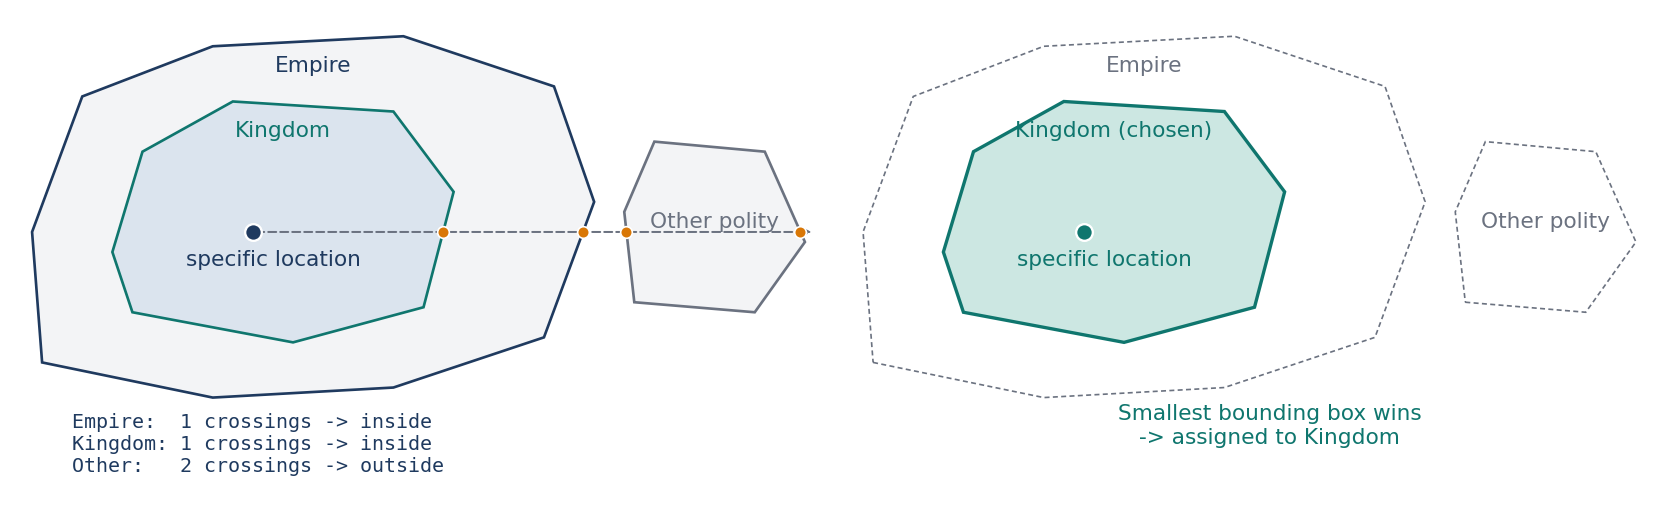

In [11]:
EMPIRE_POLYGON = [(-0.4, 0.4), (3.0, -0.3), (6.6, -0.1), (9.6, 0.9), (10.6, 3.6),
                  (9.8, 5.9), (6.8, 6.9), (3.0, 6.7), (0.4, 5.7), (-0.6, 3.0)]
KINGDOM_POLYGON = [(1.4, 1.4), (4.6, 0.8), (7.2, 1.5), (7.8, 3.8), (6.6, 5.4), (3.4, 5.6), (1.6, 4.6), (1.0, 2.6)]
OTHER_POLYGON = [(11.4, 1.6), (13.8, 1.4), (14.8, 2.8), (14.0, 4.6), (11.8, 4.8), (11.2, 3.4)]
TEST_POINT = (3.8, 3.0)
RAY_X_MAX = 15.2


def edge_crossings(point, polygon, x_max):
    px, py = point
    crossings = []
    for (x1, y1), (x2, y2) in zip(polygon, polygon[1:] + polygon[:1]):
        if (y1 > py) != (y2 > py):
            x = x1 + (py - y1) * (x2 - x1) / (y2 - y1)
            if px < x <= x_max:
                crossings.append((x, py))
    return crossings


def draw_polygon(ax, coords, face, edge, label, label_xy, lw=1.6, ls='-'):
    ax.add_patch(Polygon(coords, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, linestyle=ls))
    ax.text(*label_xy, label, fontsize=13, color=edge, ha='center')


def draw_point(ax, color):
    ax.plot(*TEST_POINT, 'o', color=color, markersize=10, markeredgecolor='white', markeredgewidth=1.4, zorder=5)
    ax.annotate('specific location', TEST_POINT, xytext=(-40, -20), textcoords='offset points', fontsize=13, color=color)


fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
draw_polygon(ax, EMPIRE_POLYGON, COLORS['light_grey'], COLORS['navy'], 'Empire', (5.0, 6.2))
draw_polygon(ax, KINGDOM_POLYGON, COLORS['light_blue'], COLORS['teal'], 'Kingdom', (4.4, 4.9))
draw_polygon(ax, OTHER_POLYGON, COLORS['light_grey'], COLORS['grey'], 'Other polity', (13.0, 3.1))
ax.add_patch(FancyArrowPatch(TEST_POINT, (RAY_X_MAX - 0.2, TEST_POINT[1]), arrowstyle='->', mutation_scale=12,
                             color=COLORS['grey'], linewidth=1.2, linestyle=(0, (4, 2))))
crossings = {name: edge_crossings(TEST_POINT, poly, RAY_X_MAX)
             for name, poly in [('Empire', EMPIRE_POLYGON), ('Kingdom', KINGDOM_POLYGON), ('Other', OTHER_POLYGON)]}
for cx, cy in sum(crossings.values(), []):
    ax.plot(cx, cy, 'o', color=COLORS['orange'], markersize=7, markeredgecolor='white', zorder=4)
draw_point(ax, COLORS['navy'])
ax.text(0.2, -0.6, '\n'.join(f'{name + ":":8s} {len(c)} crossings -> {"inside" if len(c) % 2 else "outside"}'
                             for name, c in crossings.items()),
        fontsize=12, color=COLORS['navy'], family='monospace', va='top')

ax = axes[1]
draw_polygon(ax, EMPIRE_POLYGON, 'white', COLORS['grey'], 'Empire', (5.0, 6.2), lw=1.0, ls=(0, (3, 2)))
draw_polygon(ax, KINGDOM_POLYGON, COLORS['light_teal'], COLORS['teal'], 'Kingdom (chosen)', (4.4, 4.9), lw=2.0)
draw_polygon(ax, OTHER_POLYGON, 'white', COLORS['grey'], 'Other polity', (13.0, 3.1), lw=1.0, ls=(0, (3, 2)))
draw_point(ax, COLORS['teal'])
ax.text(7.5, -1.2, 'Smallest bounding box wins\n-> assigned to Kingdom', fontsize=13, color=COLORS['teal'], ha='center')

for ax in axes:
    ax.set_xlim(-1.0, RAY_X_MAX); ax.set_ylim(-2.6, 7.4); ax.set_aspect('equal'); ax.axis('off')
fig.tight_layout()
plt.show()

### Fig 2 — Active individuals per polity, four centuries

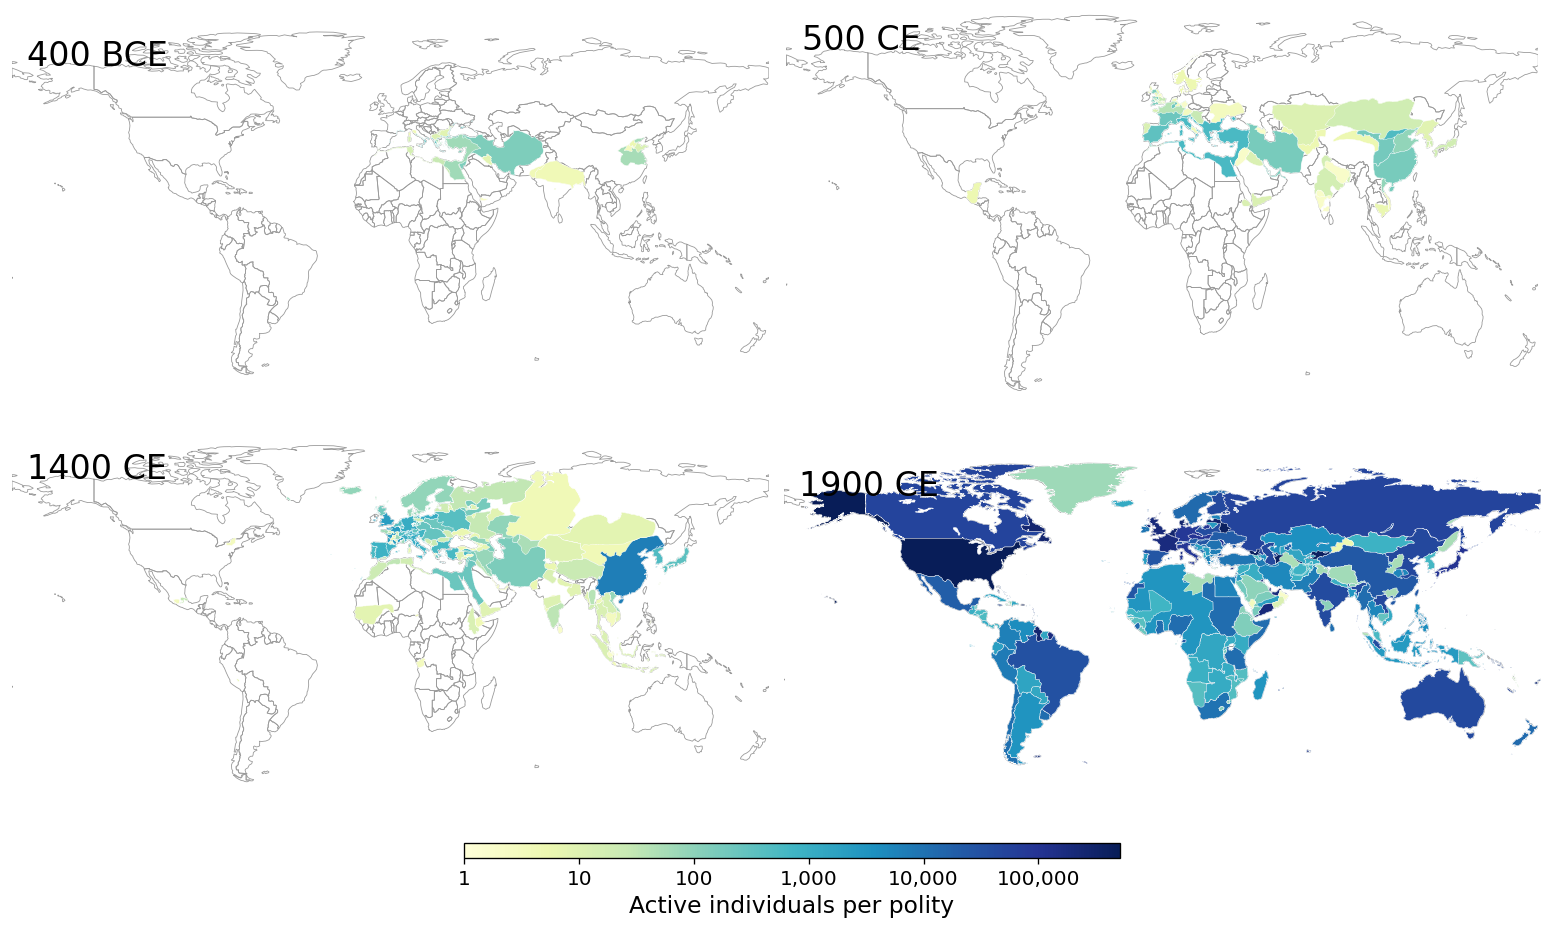

In [12]:
render_century_maps('n_all', 'Active individuals per polity')

### Fig 3 — Active scientists per polity, four centuries

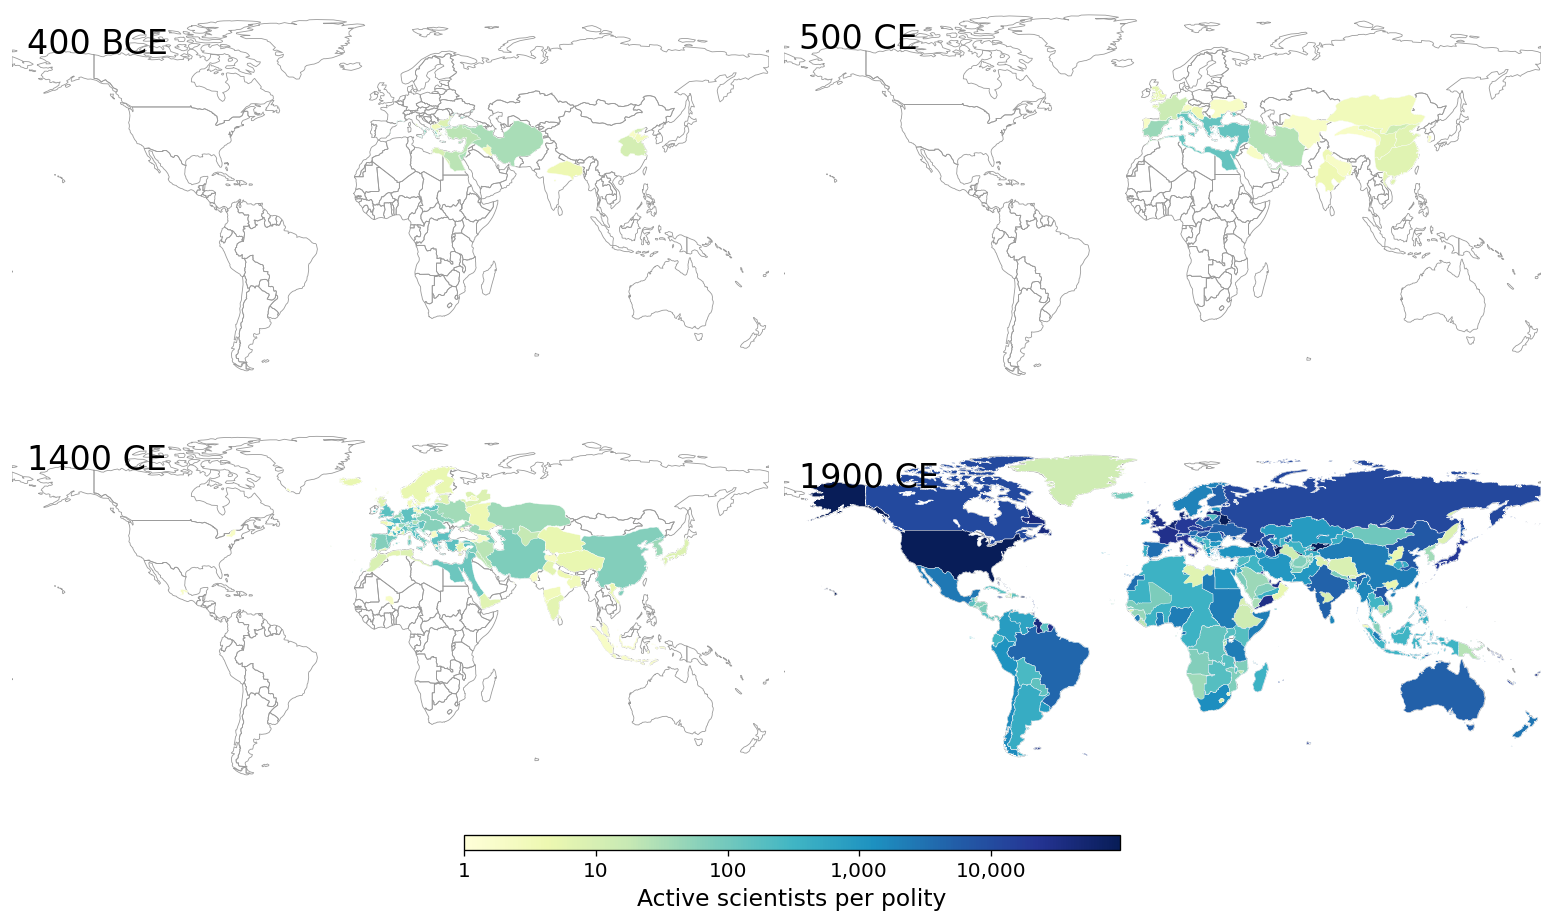

In [13]:
render_century_maps('n_scientists', 'Active scientists per polity')

### Fig 4 — Middle East zoom, polity by polity

Polities overlapping the Middle East window, clipped to it; the largest polities are labelled with their
count (smaller polities are drawn on top, so a label can sit on a smaller overlapping polity). Counts are the polity's total active individuals, not only those located inside the window.

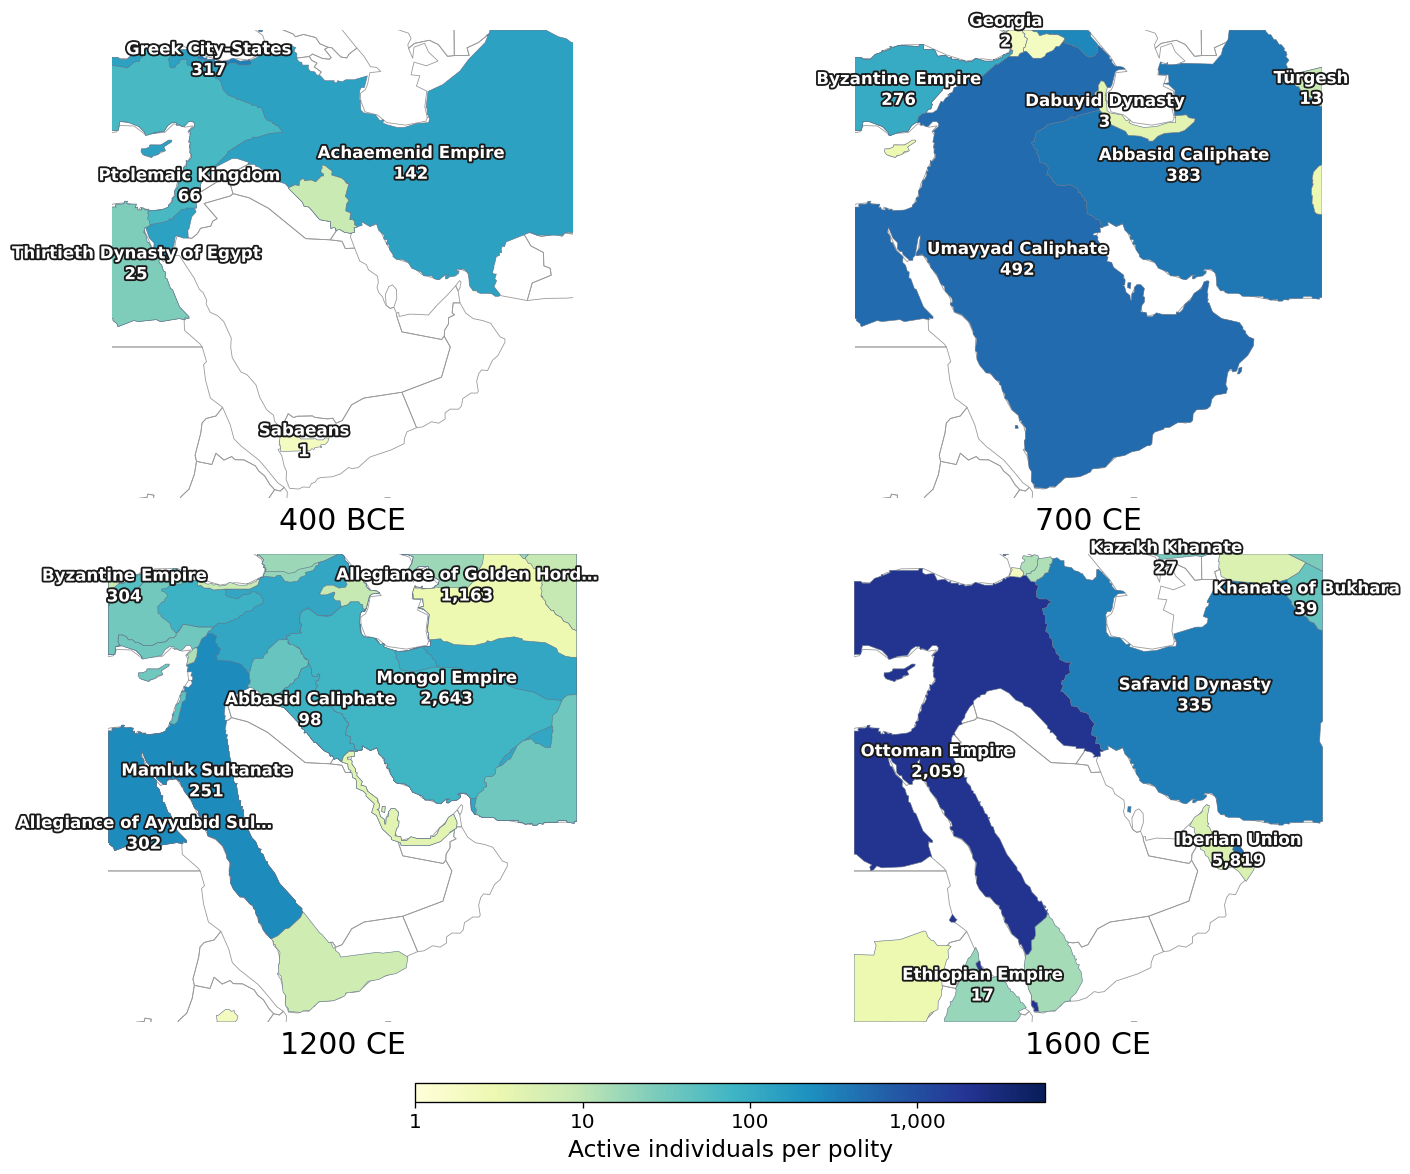

In [14]:
def shorten(name, max_chars=26):
    return name if len(name) <= max_chars else name[:max_chars - 1].rstrip() + '\u2026'


def label_polities(ax, frame):
    placed = []
    for row in frame.head(MIDDLE_EAST_LABELS * 3).itertuples():
        point = row.geometry.representative_point()
        if len(placed) >= MIDDLE_EAST_LABELS or any(
                abs(point.x - x) < LABEL_MIN_GAP[0] and abs(point.y - y) < LABEL_MIN_GAP[1] for x, y in placed):
            continue
        placed.append((point.x, point.y))
        ax.annotate(f'{shorten(row.name)}\n{row.count:,}', (point.x, point.y), ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold', zorder=4,
                    path_effects=[patheffects.withStroke(linewidth=2.2, foreground='#1a1a1a')])


window = box(*MIDDLE_EAST_BOUNDS)
middle_east_frames = {}
for century in MIDDLE_EAST_CENTURIES:
    frame = century_frame(century, 'n_all')
    frame['geometry'] = frame.geometry.intersection(window)
    middle_east_frames[century] = frame[~frame.geometry.is_empty].sort_values('count', ascending=False)

norm = Normalize(vmin=0, vmax=max(np.log10(f['count'].max() + 1) for f in middle_east_frames.values()))
lon_min, lat_min, lon_max, lat_max = MIDDLE_EAST_BOUNDS

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5))
for ax, (century, frame) in zip(axes.flatten(), middle_east_frames.items()):
    basemap.boundary.plot(ax=ax, color=COLORS['basemap'], linewidth=0.5, zorder=1)
    frame.assign(log_count=np.log10(frame['count'] + 1)).plot(
        ax=ax, column='log_count', cmap=MAP_COLORMAP, norm=norm, edgecolor='#64748b', linewidth=0.35, zorder=2)
    label_polities(ax, frame)
    ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)
    ax.set_axis_off()
    ax.text(0.5, -0.02, century_label(century), transform=ax.transAxes, fontsize=18, ha='center', va='top')
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.12, wspace=0.03, hspace=0.12)
add_log_colorbar(fig, norm, 'Active individuals per polity')
plt.show()